In [7]:
!mamba install pandas scikit-learn seaborn matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 6.363 seconds
All requested packages already installed.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   str    
 2   Customer Name  5000 non-null   str    
 3   Region         5000 non-null   str    
 4   City           5000 non-null   str    
 5   Category       5000 non-null   str    
 6   Sub-Category   5000 non-null   str    
 7   Product Name   5000 non-null   str    
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 390.7 KB


In [15]:
print(df.describe())

           Order ID     Quantity    Unit Price     Discount          Sales  \
count   5000.000000  5000.000000   5000.000000  5000.000000    5000.000000   
mean   12500.500000     2.992600  39760.904600    10.051000  106733.204870   
std     1443.520003     1.413133  22831.783946     7.084662   85108.208202   
min    10001.000000     1.000000    222.000000     0.000000     264.100000   
25%    11250.750000     2.000000  20312.250000     5.000000   39766.537500   
50%    12500.500000     3.000000  39459.500000    10.000000   83080.325000   
75%    13750.250000     4.000000  59721.750000    15.000000  156968.587500   
max    15000.000000     5.000000  79998.000000    20.000000  398485.000000   

             Profit  
count   5000.000000  
mean   15941.746982  
std    14897.684916  
min       19.120000  
25%     4892.295000  
50%    11108.525000  
75%    22467.987500  
max    89688.440000  


In [16]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='str')

In [17]:
print(df.isnull().mean()*100)

Order ID         0.0
Order Date       0.0
Customer Name    0.0
Region           0.0
City             0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Quantity         0.0
Unit Price       0.0
Discount         0.0
Sales            0.0
Profit           0.0
Payment Mode     0.0
dtype: float64


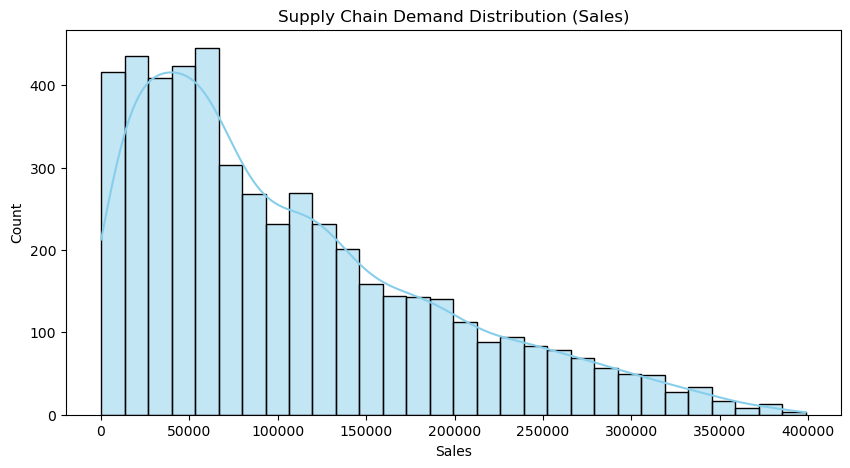

In [18]:
# 1. Distribution of Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, color='skyblue')
plt.title('Supply Chain Demand Distribution (Sales)')
plt.show()

/tmp/xpython_42/1553923571.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Category', y='Sales', estimator=sum, ci=None)


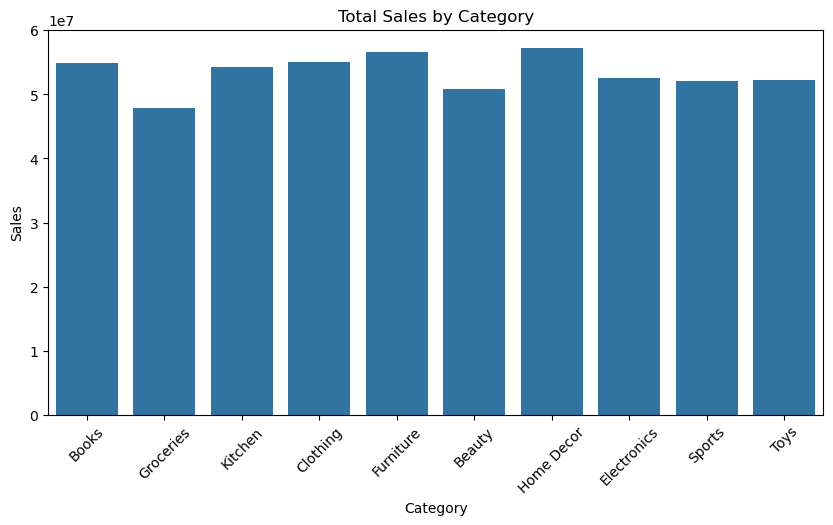

In [22]:
# Chart:  Sales by Category (Simple Bar Chart)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum, ci=None)
plt.title('Total Sales by Category')
plt.xticks(rotation=45)
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

# 1. Feature Selection: 
features = ['Region', 'Category', 'Sub-Category', 'Quantity', 'Unit Price', 'Discount']
X = df[features]
y = df['Sales']

# 2. Encoding: Convert text (Region/Category) into binary numbers
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model.predict(X_test)

print(f"--- Linear Regression Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

--- Linear Regression Model Results ---
R2 Score: 0.8756
Mean Absolute Error: 23015.55


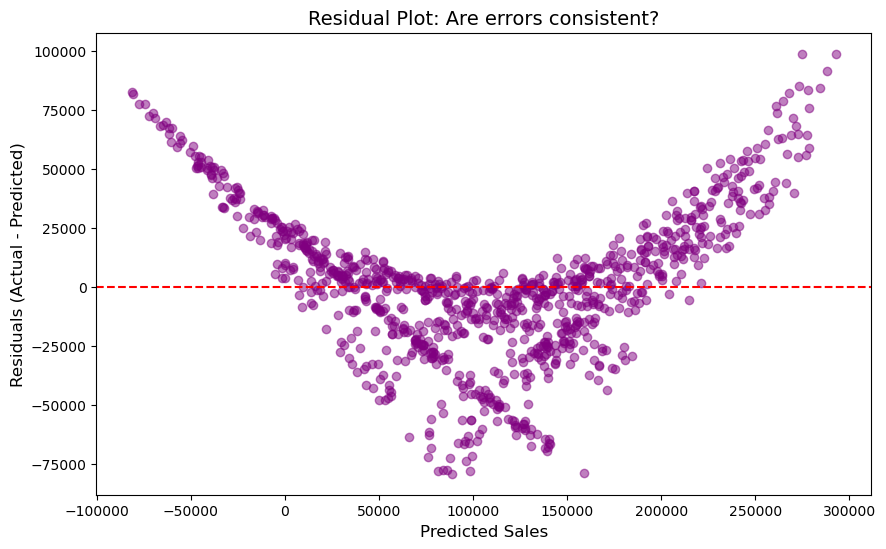

In [25]:
# Calculate Residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Are errors consistent?', fontsize=14)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.show()

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Train the model
model2 = RandomForestRegressor()
model2.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model2.predict(X_test)

print(f"--- Random Forest Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

--- Random Forest Model Results ---
R2 Score: 0.9995
Mean Absolute Error: 1251.07


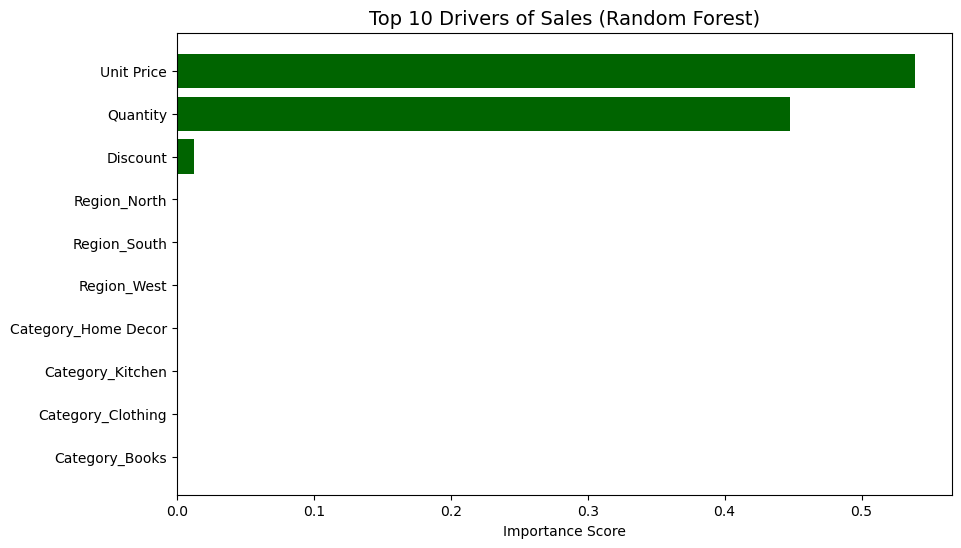

In [27]:
# Get feature importance from the Random Forest
importances = model2.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and plot the top 10
top_10 = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'], color='darkgreen')
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Sales (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Train the model
model3 = DecisionTreeRegressor()
model3.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model3.predict(X_test)

print(f"--- Decision tree Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

--- Decision tree Model Results ---
R2 Score: 0.9989
Mean Absolute Error: 1692.01


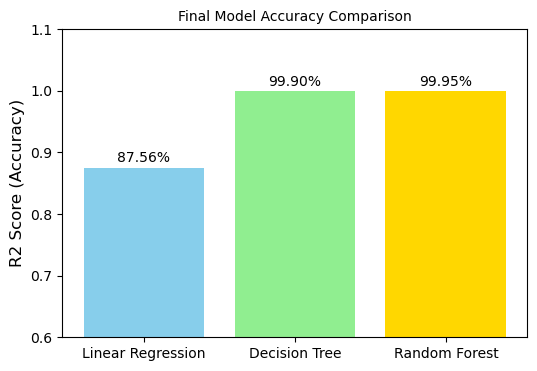

In [30]:
import matplotlib.pyplot as plt

# 1. Prepare the data
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
scores = [0.8756, 0.9990, 0.9995]

# 2. Create the bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, scores, color=['skyblue', 'lightgreen', 'gold'])

# 3. Add labels and a title
plt.title('Final Model Accuracy Comparison', fontsize=10)
plt.ylabel('R2 Score (Accuracy)', fontsize=12)
plt.ylim(0.6, 1.1) 

# Add the percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.004, f'{yval*100:.2f}%', ha='center', va='bottom')

plt.show()